In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv("LightGraffiti.csv")

# Preview
df.head()

,created_utc,score,domain,id,title,author,ups,downs,num_comments,permalink,selftext,link_flair_text,over_18,thumbnail,subreddit_id,edited,link_flair_css_class,author_flair_css_class,is_self,name,url,distinguished
0,1.357154e+09,240,i.imgur.com,15u8uo,Maybe you will like this.,MyNameCouldntBeAsLon,255,15,9,http://www.reddit.com/r/LightGraffiti/comments...,NaN,NaN,False,http://a.thumbs.redditmedia.com/XIlhubso1P1hTz...,t5_2sbql,False,NaN,NaN,False,t3_15u8uo,http://i.imgur.com/Y0IY5.gif,NaN
1,1.349191e+09,192,i.imgur.com,10tisw,Another one from our first light painting expe...,DickHickory,203,11,3,http://www.reddit.com/r/LightGraffiti/comments...,NaN,NaN,False,http://c.thumbs.redditmedia.com/Gbrb6DZ1HQAA66...,t5_2sbql,False,NaN,NaN,False,t3_10tisw,http://i.imgur.com/g9Kn8.jpg,NaN
2,1.370970e+09,181,i.imgur.com,1g4rr3,summer is poppin' off,dariustwin,189,8,11,http://www.reddit.com/r/LightGraffiti/comments...,NaN,NaN,False,http://e.thumbs.redditmedia.com/G4EkzMORMDzsw2...,t5_2sbql,False,NaN,NaN,False,t3_1g4rr3,http://i.imgur.com/dl9TJi7.gif,NaN
3,1.363032e+09,167,imgur.com,1a3lhc,Flowing light river in the forest,zachit,175,8,3,http://www.reddit.com/r/LightGraffiti/comments...,NaN,NaN,False,http://d.thumbs.redditmedia.com/MWiypV_vqsKiN3...,t5_2sbql,False,NaN,NaN,False,t3_1a3lhc,http://imgur.com/6oR4jUi,NaN
4,1.350363e+09,165,i.imgur.com,11k0e9,"First lightgraffiti pic, accidentally caught a...",chasehochs,175,10,4,http://www.reddit.com/r/LightGraffiti/comments...,NaN,NaN,False,http://a.thumbs.redditmedia.com/qHKkgfIyxYoERB...,t5_2sbql,False,NaN,NaN,False,t3_11k0e9,http://i.imgur.com/Lb5wW.jpg,NaN


In [3]:
df.info()
df.describe()

# Check missing values
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   created_utc             1000 non-null   float64
 1   score                   1000 non-null   int64  
 2   domain                  1000 non-null   str    
 3   id                      1000 non-null   str    
 4   title                   1000 non-null   str    
 5   author                  982 non-null    str    
 6   ups                     1000 non-null   int64  
 7   downs                   1000 non-null   int64  
 8   num_comments            1000 non-null   int64  
 9   permalink               1000 non-null   str    
 10  selftext                31 non-null     str    
 11  link_flair_text         0 non-null      float64
 12  over_18                 1000 non-null   bool   
 13  thumbnail               1000 non-null   str    
 14  subreddit_id            1000 non-null   str    
 15 

created_utc                  0
score                        0
domain                       0
id                           0
title                        0
author                      18
ups                          0
downs                        0
num_comments                 0
permalink                    0
selftext                   969
link_flair_text           1000
over_18                      0
thumbnail                    0
subreddit_id                 0
edited                       0
link_flair_css_class      1000
author_flair_css_class    1000
is_self                      0
name                         0
url                          0
distinguished              993
dtype: int64

In [4]:
df.info()
df.describe()

# Check missing values
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   created_utc             1000 non-null   float64
 1   score                   1000 non-null   int64  
 2   domain                  1000 non-null   str    
 3   id                      1000 non-null   str    
 4   title                   1000 non-null   str    
 5   author                  982 non-null    str    
 6   ups                     1000 non-null   int64  
 7   downs                   1000 non-null   int64  
 8   num_comments            1000 non-null   int64  
 9   permalink               1000 non-null   str    
 10  selftext                31 non-null     str    
 11  link_flair_text         0 non-null      float64
 12  over_18                 1000 non-null   bool   
 13  thumbnail               1000 non-null   str    
 14  subreddit_id            1000 non-null   str    
 15 

created_utc                  0
score                        0
domain                       0
id                           0
title                        0
author                      18
ups                          0
downs                        0
num_comments                 0
permalink                    0
selftext                   969
link_flair_text           1000
over_18                      0
thumbnail                    0
subreddit_id                 0
edited                       0
link_flair_css_class      1000
author_flair_css_class    1000
is_self                      0
name                         0
url                          0
distinguished              993
dtype: int64

In [6]:
# Drop duplicates
df = df.drop_duplicates()

# Fill missing values (forward fill)
df = df.ffill()

In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include=['object', 'string']).columns:
    df[col] = le.fit_transform(df[col])

In [10]:
df.columns = df.columns.str.strip()

In [11]:
print(df.columns.tolist())

['created_utc', 'score', 'domain', 'id', 'title', 'author', 'ups', 'downs', 'num_comments', 'permalink', 'selftext', 'link_flair_text', 'over_18', 'thumbnail', 'subreddit_id', 'edited', 'link_flair_css_class', 'author_flair_css_class', 'is_self', 'name', 'url', 'distinguished']


In [13]:
import numpy as np
from sklearn.model_selection import train_test_split

X = np.array([[1, 2], [3, 4], [5, 6], [7, 8]])
y = np.array([0, 1, 0, 1])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
import numpy as np

print("y_train distribution:", np.bincount(y_train))
print("y_test distribution:", np.bincount(y_test))
print("Predictions distribution:", np.bincount(dt_preds))

y_train distribution: [2 1]
y_test distribution: [0 1]
Predictions distribution: [1]


In [17]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

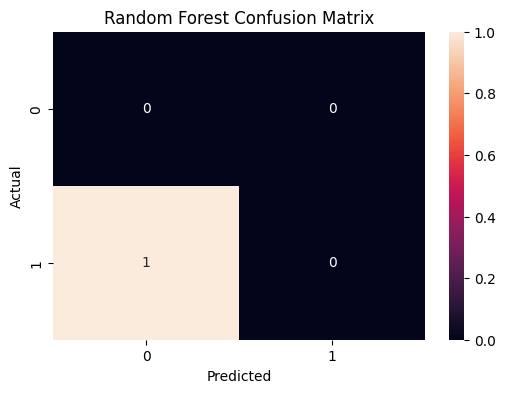

In [18]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, rf_preds), annot=True, fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()